Today's topics:
* the shape of a distribution
* percentiles and the interquartile range
* histograms

# How long does a perovskite solar cell last?

Perovskite solar cells are the fastest-improving photovoltaic technology on record. In
about fifteen years their record efficiency went from 4% to above 26%, level with silicon.

<img src="https://upload.wikimedia.org/wikipedia/commons/7/73/Perovskite_photovoltaics_efficiency_chart_2022.png" alt="NREL chart of record perovskite cell efficiencies over time against other PV technologies" width=560/>

(Record research-cell efficiencies over time. National Renewable Energy Laboratory, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Perovskite_photovoltaics_efficiency_chart_2022.png), public domain.)

The catch is that they degrade. Light, heat, and moisture all attack the perovskite
layer, and a cell that starts at 20% can be at 12% within a week.

So a manufacturer who wants to sell these has to decide: *what loss can we promise
that most cells will stay under?*

That promise is a line drawn across a distribution, and it's set by the tail of the
distribution, not by its center.

Here's a dataset for estimating that loss. Between 2019 and 2022, a group at Helmholtz-Zentrum
Berlin ran 2245 perovskite cells of many different designs through the same ageing test:
150 hours under one-sun illumination, tracking each cell's power output the whole time.

In [1]:
#@title Load the perovskite ageing dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import numpy as np
import pandas as pd

_file = 'perovskite_pv_aging.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_alive = _table[_table['pce_max'] >= 1.0]

peak_pce = _alive['pce_max'].to_numpy()
pce_loss = (100.0 * (_alive['pce_max'] - _alive['final_pce']) / _alive['pce_max']).to_numpy()

print(f'Loaded {len(_table)} perovskite solar cells from {_file}')
print(f'  {len(_table) - len(_alive)} cells never reached 1% efficiency and are left out')
print(f'  peak_pce: {len(peak_pce)} values (%, best efficiency during the 150 h test)')
print(f'  pce_loss: {len(pce_loss)} values (%, share of that peak lost by the end)')

Loaded 2245 perovskite solar cells from perovskite_pv_aging.csv
  13 cells never reached 1% efficiency and are left out
  peak_pce: 2232 values (%, best efficiency during the 150 h test)
  pce_loss: 2232 values (%, share of that peak lost by the end)


<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs41467-023-40585-3/MediaObjects/41467_2023_40585_Fig1_HTML.png" alt="Two ageing traces marked with maximum PCE and PCE at 150 hours, and violin plots of relative PCE loss by efficiency group, from Hartono et al. 2023" width=620/>

(Fig. 1 of [Hartono et al., *Nature Communications* 14, 4869 (2023)](https://doi.org/10.1038/s41467-023-40585-3), [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).)

Panel (a) is one cell's test, and it marks the two numbers we keep per cell.

`peak_pce` is the best efficiency the cell reached. `pce_loss` is the share of that peak
it had lost by 150 hours.

Panel (b) is their summary of the loss, drawn with medians and interquartile ranges,
which are the two ideas we build today.

Let's look at the loss first, sorted, as we did last time:

In [2]:
import numpy as np

print(np.sort(pce_loss)[:5])
print(np.sort(pce_loss)[-5:])

[0.18126446 0.18607495 0.1980645  0.21603184 0.22537223]
[100. 100. 100. 100. 100.]


A few cells lost nothing at all, and a few lost everything. The interesting part is the
two thousand in between.

In [3]:
print(f'mean:   {np.mean(pce_loss):.1f}%')
print(f'median: {np.median(pce_loss):.1f}%')

mean:   28.8%
median: 23.5%


The mean sits well above the median. In L05 that gap was our first clue about the shape.

Now we can look at the whole shape directly.

# Histograms: seeing the shape

Last time the histogram was hidden in a collapsed cell. Here's the whole recipe, four
lines:

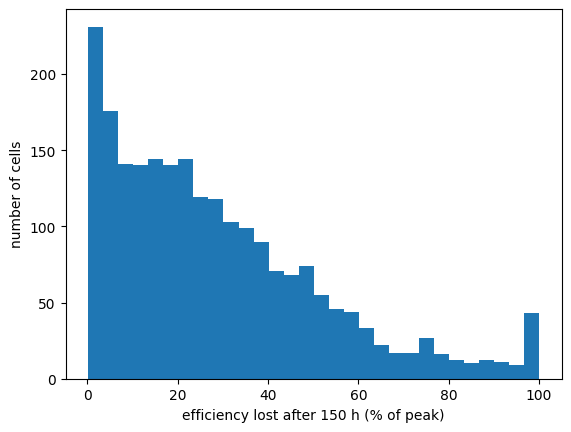

In [4]:
import matplotlib.pyplot as plt

plt.hist(pce_loss, bins=30)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.ylabel('number of cells')
plt.show()

Here `plt.hist` sorts the values into `bins` equal-width intervals and draws one bar per
interval. The height of each bar is the count of cells that fall in it.

> This is a recipe to copy, not syntax to memorize. We'll take matplotlib apart properly
> in a later lecture!

This one is lopsided. Most cells lost a quarter or less, and then a long tail runs out to
the right, all the way to the cells that lost everything.

## Bins

Note that `bins` is a resolution setting. Let's try a coarse one:

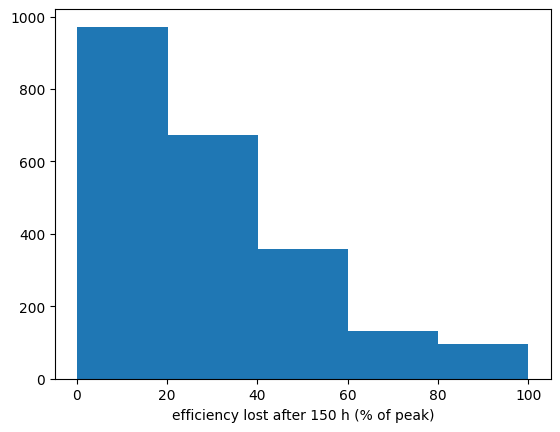

In [5]:
plt.hist(pce_loss, bins=5)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.show()

Five bins hide the shape. Now a fine one:

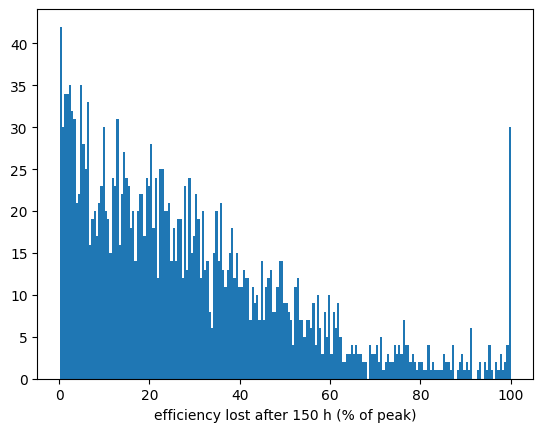

In [6]:
plt.hist(pce_loss, bins=200)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.show()

Two hundred bins turn it into noise. For a couple of thousand values, something like 30
to 50 bins works, and the tail is there at every setting.

## The other array

Same recipe, swapping in the peak efficiency:

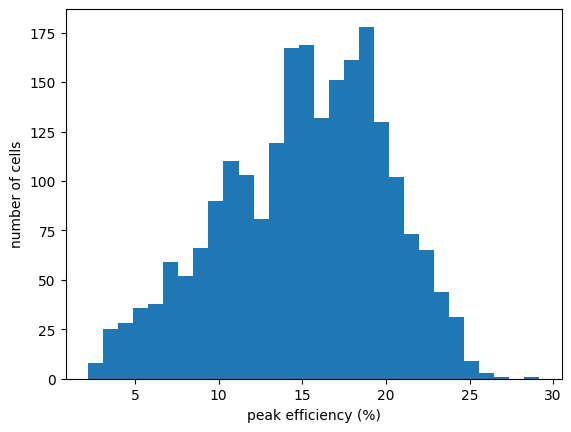

In [7]:
plt.hist(peak_pce, bins=30)
plt.xlabel('peak efficiency (%)')
plt.ylabel('number of cells')
plt.show()

This one is a hump around 15% with tails of similar length on each side.

We call the shape on the left **symmetric**: the two tails match and the mean sits on
the median. That's roughly our peak efficiency.

The shape on the right is **right-skewed**: a long tail toward high values, with the
mean pulled out along it, past the median. That's our loss.

Let's check the symmetric claim the same way we checked the loss:

In [8]:
print(f'mean:   {np.mean(peak_pce):.1f}%')
print(f'median: {np.median(peak_pce):.1f}%')

mean:   15.1%
median: 15.4%


For the efficiency the two agree. For the loss they didn't.

## Two shapes, two mechanisms

Why would the two shapes differ?

Efficiency is what's left after many small, independent losses: reflection,
recombination, resistance, each taking a few percent.

Add up many small effects and we get a symmetric hump. This is the origin of the
**normal** [Gaussian] distribution, and it's why repeated measurements of almost
anything look bell-shaped.

Degradation is different. Here the chemistry is self-reinforcing: a defect lets in
moisture, and the moisture creates more defects.

A process whose rate grows with its own progress produces a few runaway cells and a
long tail. Shapes like this are often close to **lognormal**, which just means the
*logarithm* of the values is normal.

# Percentiles: where a value sits

The median is the value with half the data below it. A **percentile** generalizes that
idea: the 25th percentile has a quarter of the data below it, the 90th has nine tenths.

In NumPy this is `np.percentile`, which takes the array and a level between 0 and 100.
Let's start with 50, which we already know:

In [9]:
print(np.percentile(pce_loss, 50))
print(np.median(pce_loss))

23.480884854184502
23.480884854184502


Same number! Now the quartiles, the 25th and 75th percentiles:

In [10]:
q1 = np.percentile(pce_loss, 25)
q3 = np.percentile(pce_loss, 75)
print(f'Q1 = {q1:.1f}%')
print(f'Q3 = {q3:.1f}%')

Q1 = 10.5%
Q3 = 41.3%


So the middle half of the cells lost somewhere between a tenth and two fifths of their
peak.

We can pass an array of levels too, and then the result is an array in the same order:

In [11]:
levels = np.array([10, 25, 50, 75, 90])
print(np.percentile(pce_loss, levels))

[ 3.42616158 10.45722097 23.48088485 41.26072446 60.70221885]


Read this with the histogram in mind. The 10th percentile is close to the median and
the 90th is far from it, and that asymmetry *is* the right skew, in numbers.

What about the ends?

In [12]:
print(np.percentile(pce_loss, 0), np.min(pce_loss))
print(np.percentile(pce_loss, 100), np.max(pce_loss))

0.18126445690848456 0.18126445690848456
100.00000000000001 100.00000000000001


So the 0th percentile is the minimum and the 100th is the maximum.

> When a level falls between two data points the function interpolates, so a percentile
> need not be a value that actually appears in the array.

## The interquartile range

Last time we measured spread with the standard deviation. Now the quartiles give us
another measure:

$$\text{IQR} = Q_3 - Q_1$$

Here:
* $Q_1$ is the 25th percentile
* $Q_3$ is the 75th percentile
* so the IQR is the width of the middle half of the data

In [13]:
iqr = q3 - q1
print(f'IQR: {iqr:.1f}%')

IQR: 30.8%


The IQR is computed only from the middle 50% of the values, so by construction the
tail can't change it. We might say it's more **robust**, in the same sense the median
was last time.

How does it compare with the standard deviation?

In [14]:
print(f'std: {np.std(pce_loss):.1f}%')
print(f'IQR / std = {iqr / np.std(pce_loss):.2f}')

std: 23.3%
IQR / std = 1.32


For a bell-shaped distribution that ratio comes out near 1.35.

This one lands close to it despite the tail, because the loss is capped at 100%. A cell
can't lose more than everything, so there's no counterpart here to the 1710 MPa alloy
that stretched the standard deviation in L05.

# Specifications are percentiles

Back to the manufacturer. Suppose the promise is written as "nine cells in ten lose no
more than *this much* in the first 150 hours".

Nine in ten below a value is the definition of the 90th percentile:

In [15]:
print(f'{np.percentile(pce_loss, 90):.0f}%')

61%


So the honest promise is about 60%.

Compare that with the mean:

In [16]:
print(f'{np.mean(pce_loss):.0f}%')

29%


Roughly half. A datasheet quoting the mean would be broken by a third of the cells.

Note the direction of the argument. A specification sets a line that every part must
clear, so what matters is the *bad* tail of whatever we manufacture, and a percentile
describes that tail.

### [Check your understanding]

Now the same tools on the other array, `peak_pce`, where *higher* is better.

1. Print the 10th, 50th, and 90th percentiles of `peak_pce` in one call. Is the spacing
   on the two sides of the median more even than it was for the loss?
2. Researchers in a lab decide to publish only cells in their top quarter by
   efficiency. What peak efficiency does a cell need to *exceed* to be published?
3. Compute the IQR and the standard deviation of `peak_pce`. For a bell-shaped
   distribution the IQR is about 1.35 times the standard deviation. How close is this
   one?

*Optional challenge:* find the peak efficiency exceeded by only 1 cell in 100.

## A number for the skew

So far we've been reading the skew off the histogram and off the gap between mean and
median. SciPy will put a number on it.

You don't need to learn this, it's just worth knowing it exists:

In [17]:
#@title Optional tool glimpse: scipy.stats.skew (click ▶ to run) { display-mode: "form" }
from scipy.stats import skew

print(f'peak efficiency: {skew(peak_pce):.2f}')
print(f'efficiency lost: {skew(pce_loss):.2f}')

peak efficiency: -0.32
efficiency lost: 1.07


Zero is symmetric, positive is a right tail, negative is a left tail. The efficiency is
slightly left-skewed; the loss is strongly right-skewed.

# How long does a perovskite cell last?

Not one answer. After 150 hours half the cells had lost under a quarter of their peak,
nine in ten had lost under 60%, and a few had died.

So our description of a distribution now has three parts: a center (mean or median),
a spread (standard deviation or IQR), and a *shape*, which the histogram shows and the
percentiles measure.

Put the guarantee on a percentile.

## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)
- [VanderPlas: Histograms and binnings](https://jakevdp.github.io/PythonDataScienceHandbook/04.05-histograms-and-binnings.html)
- [NumPy documentation: `np.percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
- [Hartono et al. (2023), the paper behind today's data](https://doi.org/10.1038/s41467-023-40585-3)